In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
df=pd.read_csv('/content/ecommerce_product_demand.csv')

In [5]:
df.head()

,Record_ID,Date,Product_ID,Category,Region,Sales_Channel,Price,Discount_Percentage,Marketing_Spend,Website_Visits,...,Return_Rate,Holiday_Flag,Promotion_Flag,New_Product_Flag,Delivery_Days,Month,Season,Demand_Units,Estimated_Revenue,Inventory_Turnover_Index
0,REC003519,2022-01-01,PROD01165,Home & Kitchen,North,Mobile App,19.47,5,191.12,1008,...,5.81,0,1,0,2,1,Winter,40,739.86,4.71
1,REC000902,2022-01-01,PROD00306,Books,North,Website,45.35,5,118.17,990,...,0.95,0,0,0,2,1,Winter,17,732.40,1.76
2,REC001983,2022-01-01,PROD00819,Grocery,North,Marketplace,61.27,20,327.59,1023,...,9.80,0,0,0,4,1,Winter,18,882.29,1.78
3,REC003508,2022-01-01,PROD00157,Electronics,Central,Mobile App,23.25,15,87.48,1016,...,0.20,1,0,0,1,1,Winter,101,1996.01,11.99
4,REC001949,2022-01-01,PROD00775,Books,East,Mobile App,22.87,0,96.49,1024,...,1.50,0,0,0,7,1,Winter,9,205.83,1.41


In [6]:
df.isnull().sum()

,0
Record_ID,0
Date,0
Product_ID,0
Category,0
Region,0
Sales_Channel,0
Price,0
Discount_Percentage,0
Marketing_Spend,0
Website_Visits,0


In [7]:
df.dtypes

,0
Record_ID,object
Date,object
Product_ID,object
Category,object
Region,object
Sales_Channel,object
Price,float64
Discount_Percentage,int64
Marketing_Spend,float64
Website_Visits,int64


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
print(df['Category'].unique())
print(df['Sales_Channel'].unique())

['Home & Kitchen' 'Books' 'Grocery' 'Electronics' 'Toys' 'Fashion'
 'Sports' 'Beauty']
['Mobile App' 'Website' 'Marketplace']


In [11]:
df.describe()

,Date,Price,Discount_Percentage,Marketing_Spend,Website_Visits,Search_Interest,Competitor_Price,Stock_Availability,Customer_Rating,Return_Rate,Holiday_Flag,Promotion_Flag,New_Product_Flag,Delivery_Days,Month,Demand_Units,Estimated_Revenue,Inventory_Turnover_Index
count,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2023-12-28 09:07:01.199999744,37.279029,12.683125,113.750928,1000.243625,55.100880,36.955402,86.868013,4.079428,7.055989,0.115750,0.318750,0.145375,5.531500,6.451750,37.211750,923.291911,4.231042
min,2022-01-01 00:00:00,2.360000,0.000000,7.860000,892.000000,5.000000,2.440000,44.600000,1.910000,0.200000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,74.250000,0.100000
25%,2022-12-29 00:00:00,19.477500,5.000000,55.857500,979.000000,41.870000,19.240000,79.850000,3.690000,4.400000,0.000000,0.000000,0.000000,3.000000,3.000000,21.000000,559.485000,2.420000
50%,2024-01-05 00:00:00,29.625000,10.000000,89.815000,1000.000000,55.075000,29.535000,87.845000,4.090000,6.950000,0.000000,0.000000,0.000000,6.000000,6.000000,33.000000,817.380000,3.720000
75%,2024-12-24 00:00:00,46.620000,20.000000,143.057500,1021.000000,68.552500,46.377500,95.892500,4.510000,9.670000,0.000000,1.000000,0.000000,8.000000,9.000000,48.000000,1177.605000,5.480000
max,2025-12-31 00:00:00,466.640000,30.000000,1291.060000,1118.000000,100.000000,344.640000,100.000000,5.000000,23.910000,1.000000,1.000000,1.000000,10.000000,12.000000,245.000000,4772.640000,20.000000
std,NaN,27.586851,8.509584,89.421344,30.779582,19.692757,27.244937,10.441710,0.563942,3.798319,0.319945,0.466021,0.352501,2.877333,3.456901,23.237871,515.541895,2.554348


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Total_Revenue'] = df['Price'] * df['Demand_Units']
category_summary = df.groupby('Category')[['Demand_Units', 'Total_Revenue']].sum()
print(category_summary)

                Demand_Units  Total_Revenue
Category                                   
Beauty                 34879      997780.66
Books                  24362      701184.17
Electronics            47634     1369457.55
Fashion                41514     1242145.86
Grocery                49943     1389607.26
Home & Kitchen         38387     1102839.49
Sports                 32676      926277.62
Toys                   28299      797030.60


/tmp/ipykernel_3853/3361083351.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Date').resample('M')['Demand_Units'].sum().plot(kind='line', title='Monthly Demand Trend')


<Axes: title={'center': 'Monthly Demand Trend'}, xlabel='Date'>

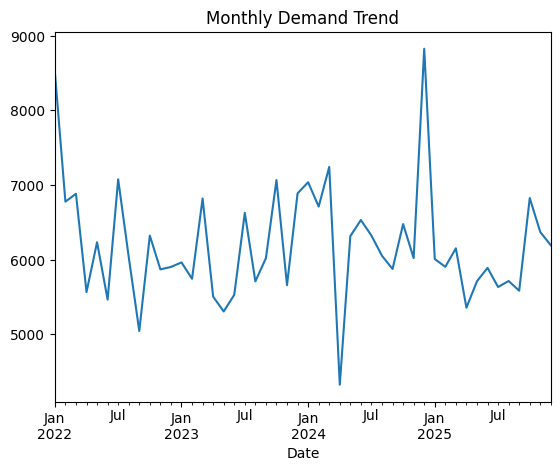

In [14]:
df.set_index('Date').resample('M')['Demand_Units'].sum().plot(kind='line', title='Monthly Demand Trend')

Text(0.5, 1.0, 'Feature Correlation Matrix')

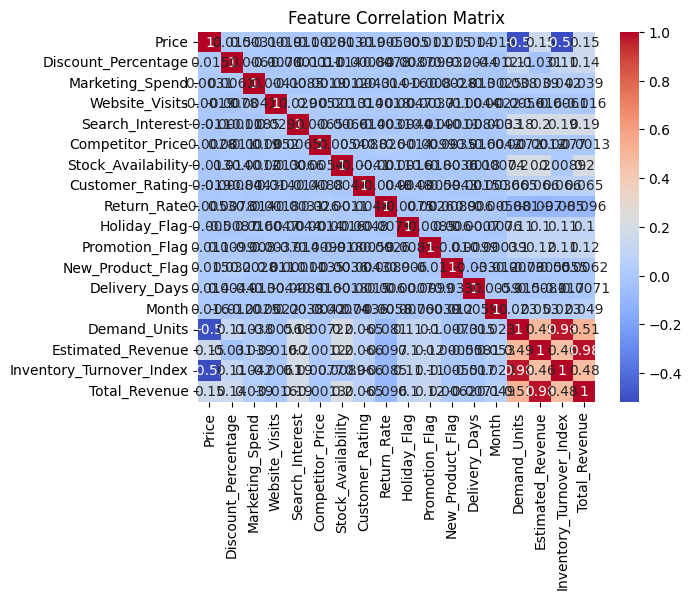

In [15]:
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')

<Axes: title={'center': 'Monthly Demand Trend'}, xlabel='Date'>

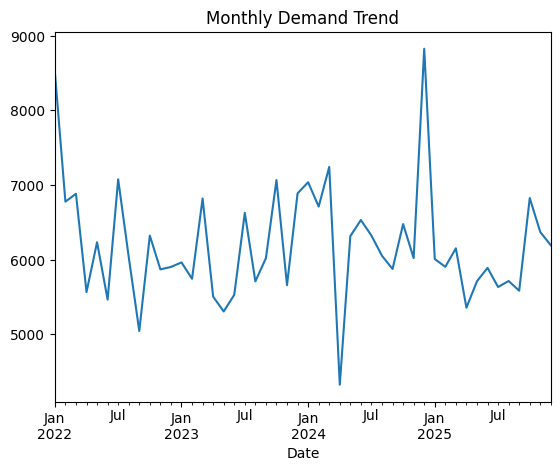

In [16]:
df.set_index('Date').resample('ME')['Demand_Units'].sum().plot(kind='line', title='Monthly Demand Trend')

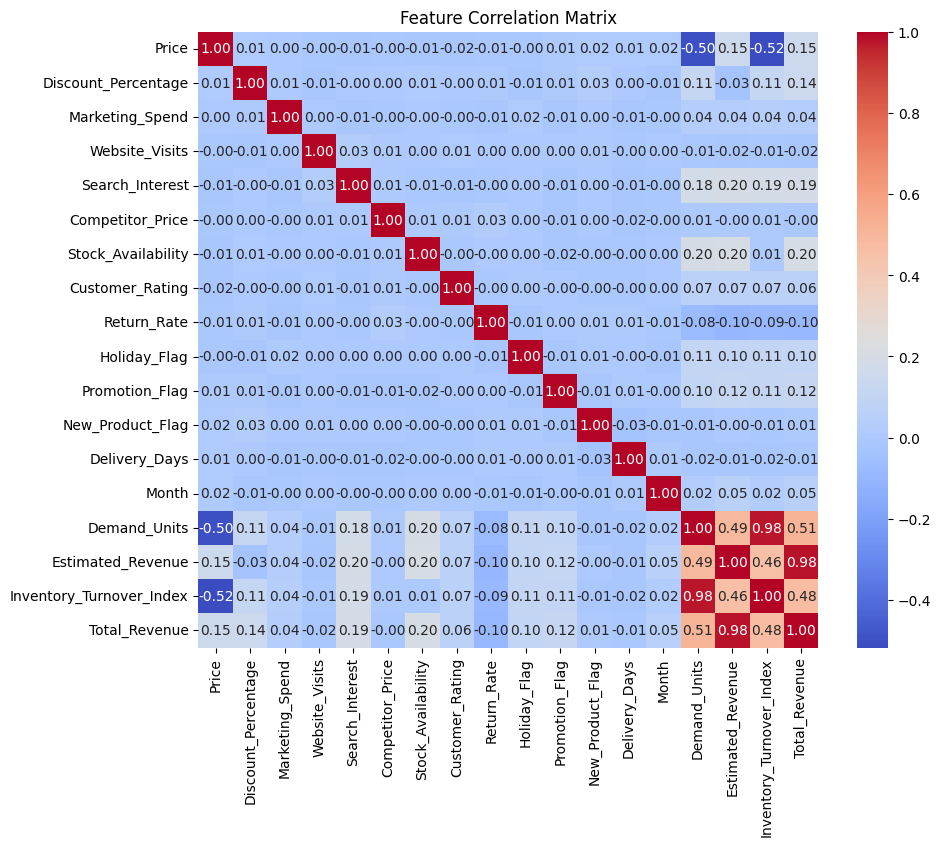

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(include=['float64', 'int64']).corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Feature Correlation Matrix')
plt.show()

In [18]:
df.select_dtypes(include=['float64', 'int64']).corr()['Demand_Units'].sort_values(ascending=False)

,Demand_Units
Demand_Units,1.000000
Inventory_Turnover_Index,0.975045
Total_Revenue,0.508380
Estimated_Revenue,0.489892
Stock_Availability,0.197380
Search_Interest,0.179198
Discount_Percentage,0.114666
Holiday_Flag,0.106285
Promotion_Flag,0.103402
Customer_Rating,0.065083


In [19]:
df.groupby('Promotion_Flag')['Demand_Units'].mean()

,Demand_Units
Promotion_Flag,
0,35.568257
1,40.724314


<Axes: title={'center': 'Demand by Channel'}, xlabel='Sales_Channel'>

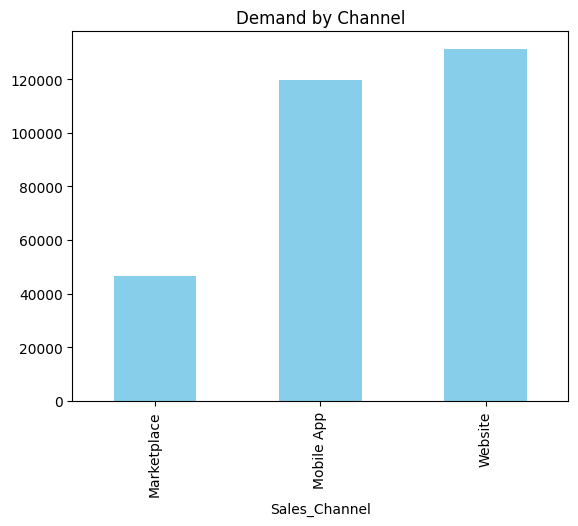

In [20]:
df.groupby('Sales_Channel')['Demand_Units'].sum().plot(kind='bar', color='skyblue', title='Demand by Channel')

<Axes: title={'center': 'Revenue Share by Channel'}, ylabel='Total_Revenue'>

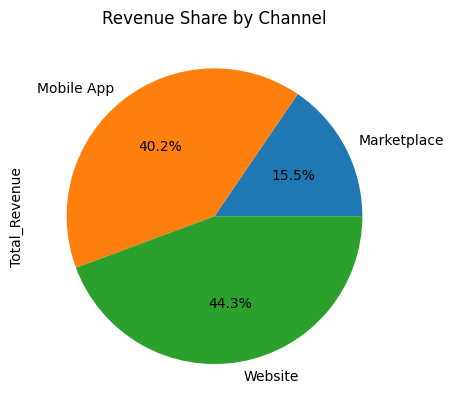

In [21]:
df.groupby('Sales_Channel')['Total_Revenue'].sum().plot(kind='pie', autopct='%1.1f%%', title='Revenue Share by Channel')

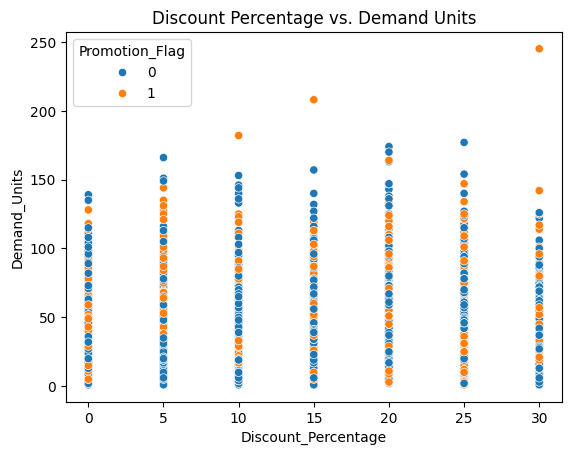

In [22]:
sns.scatterplot(data=df, x='Discount_Percentage', y='Demand_Units', hue='Promotion_Flag')
plt.title('Discount Percentage vs. Demand Units')
plt.show()

In [23]:
df.groupby('Category')['Return_Rate'].mean().sort_values(ascending=False)

,Return_Rate
Category,
Beauty,7.240436
Home & Kitchen,7.139698
Sports,7.123646
Electronics,7.118519
Toys,7.021103
Books,6.984054
Fashion,6.923848
Grocery,6.909489


In [24]:
import numpy as np

# Generate realistic competitor pricing based on your base Price
np.random.seed(42)
df['Competitor_Price'] = (df['Price'] * np.random.uniform(0.85, 1.15, size=len(df))).round(2)

# Feature engineering for competitor comparison
df['Price_Difference'] = (df['Price'] - df['Competitor_Price']).round(2)
df['Price_Ratio'] = (df['Price'] / df['Competitor_Price']).round(4)

print(df[['Price', 'Competitor_Price', 'Price_Difference', 'Price_Ratio']].head())

   Price  Competitor_Price  Price_Difference  Price_Ratio
0  19.47             18.74              0.73       1.0390
1  45.35             51.48             -6.13       0.8809
2  61.27             65.53             -4.26       0.9350
3  23.25             23.94             -0.69       0.9712
4  22.87             20.51              2.36       1.1151


In [25]:
# Configure Git credentials
!git config --global user.name "srivastava935shreya-create"
!git config --global user.email "srivastava935shreya@gmail.com"

# Switch to your feature branch (creates it locally if not checked out)
!git checkout -b shreya-srivastava || !git checkout shreya-srivastava

# Add, commit, and push directly to your feature branch
!git add first_project.ipynb
!git commit -m "Add competitor pricing and price elasticity features"
!git push origin shreya-srivastava

fatal: not a git repository (or any of the parent directories): .git
/bin/bash: line 1: !git: command not found
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
